# 06 — Cluster 'Other' Articles to Discover Missing Subtopics

Pipeline:
1. Filter articles labeled `Other`
2. Embed text with `sentence-transformers` (all-MiniLM-L6-v2 — fast, good quality)
3. **Primary**: BERTopic (UMAP + HDBSCAN) — auto-generates topic labels
4. **Fallback**: K-Means if BERTopic is too slow or install is blocked
5. Evaluate clusters and decide which to promote as new subtopics

Output: `data/other_clustered.csv` + updated `SUBTOPIC_KEYWORDS` suggestions

In [5]:
# pip install sentence-transformers bertopic umap-learn hdbscan
# pip install scikit-learn  # for K-Means fallback

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

df_all = pd.read_csv('data/classified_articles.csv', parse_dates=['date'])

# Isolate 'Other' articles (deduplicate by article id first)
df_other = (
    df_all[df_all['subtopic'] == 'Other']
    .drop_duplicates(subset='id')
    .copy()
    .reset_index(drop=True)
)

print(f"'Other' articles: {len(df_other)}")
df_other[['date', 'headline']].head(5)

'Other' articles: 17328


,date,headline
0,2025-06-03,AI pioneer announces non-profit to develop ‘ho...
1,2025-12-12,Trump signs executive order aimed at preventin...
2,2025-11-22,Meet the AI workers who tell their friends and...
3,2025-11-20,More than half of UK novelists believe AI will...
4,2025-08-06,Meet the AI vegans


## Step 1 — Prepare Text
Use headline + first 512 chars of body. Embeddings degrade on very long text.

In [6]:
df_other['text_input'] = (
    df_other['headline'].fillna('') + '. ' +
    df_other['body'].fillna('').str[:512]
)

# Drop if text is basically empty
df_other = df_other[df_other['text_input'].str.len() > 30].reset_index(drop=True)
print(f'Articles after quality filter: {len(df_other)}')

Articles after quality filter: 17328


## Step 2 — Embed with Sentence-Transformers
`all-MiniLM-L6-v2` is 80MB, runs on CPU, ~500 articles/min. For 2k articles expect ~4 min.

In [7]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')

print('Encoding... (this takes a few minutes on CPU)')
embeddings = model.encode(
    df_other['text_input'].tolist(),
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True  # cosine similarity friendly
)

print(f'Embedding shape: {embeddings.shape}')  # (n_articles, 384)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding... (this takes a few minutes on CPU)


Batches:   0%|          | 0/271 [00:00<?, ?it/s]

Embedding shape: (17328, 384)


## Step 3 — BERTopic (Primary Method)

Why BERTopic over plain K-Means:
- Automatically determines number of topics (no need to guess K)
- Outputs interpretable keyword labels per cluster (e.g., `robot_manufacturing_factory_automation`)
- HDBSCAN handles noise/outlier articles naturally (assigned to topic -1)
- UMAP reduces 384-dim embeddings to 5-dim before clustering — much more accurate than K-Means on raw embeddings

In [16]:
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

# UMAP: reduce to 5D before clustering
umap_model = UMAP(
    n_components=5,
    n_neighbors=15,
    min_dist=0.0,
    metric='cosine',
    random_state=42
)

# HDBSCAN: density-based clustering
# min_cluster_size: minimum articles to form a topic
# Adjust based on your corpus size. Rule of thumb: ~1-2% of dataset
min_cluster = max(10, len(df_other) // 80)
hdbscan_model = HDBSCAN(
    min_cluster_size=min_cluster,
    min_samples=5,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True
)

# CountVectorizer: adaptive min_df/max_df to avoid ValueError on small corpora
n_docs = len(df_other)
# min_df = min(20, int(n_docs * 0.002))          # at least 1% of docs, floor at 2
# max_df = max(min_df + 1, int(n_docs * 0.85)) # always strictly > min_df
min_df = 0.02
max_df = 0.95
print(f'Corpus: {n_docs} docs | min_df: {min_df} | max_df: {max_df}')

vectorizer = CountVectorizer(
    stop_words='english',
    ngram_range=(1, 2),
    min_df=min_df,
    max_df=max_df
)

topic_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer,
    top_n_words=10,
    verbose=True
)

topics, probs = topic_model.fit_transform(
    df_other['text_input'].tolist(),
    embeddings=embeddings  # reuse precomputed embeddings
)

df_other['topic_id'] = topics

2026-02-19 14:19:32,197 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


Corpus: 17328 docs | min_df: 0.02 | max_df: 0.95


2026-02-19 14:19:38,172 - BERTopic - Dimensionality - Completed ✓
2026-02-19 14:19:38,173 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-02-19 14:19:38,414 - BERTopic - Cluster - Completed ✓
2026-02-19 14:19:38,415 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-02-19 14:19:40,625 - BERTopic - Representation - Completed ✓


In [17]:
# Topic overview — keyword labels auto-generated by BERTopic
topic_info = topic_model.get_topic_info()
print(f"Topics found: {len(topic_info) - 1} (excluding outlier topic -1)")
print(f"Outlier articles (topic -1): {(df_other['topic_id'] == -1).sum()}")
topic_info

Topics found: 1 (excluding outlier topic -1)
Outlier articles (topic -1): 0


,Topic,Count,Name,Representation,Representative_Docs
0,0,15733,0_gaza_military_biden_israel,"[gaza, military, biden, israel, tariffs, putin...",[Reeves ‘going nowhere’ and has Starmer’s full...
1,1,1595,1_pep guardiola_wickets_match report_poker mac...,"[pep guardiola, wickets, match report, poker m...",[‘We are favourites’: McLaren are ‘team to bea...


In [18]:
# Inspect top keywords per topic
for topic_id in topic_info['Topic'].tolist():
    if topic_id == -1:
        continue
    words = topic_model.get_topic(topic_id)
    kw_str = ', '.join([w for w, _ in words[:8]])
    count = (df_other['topic_id'] == topic_id).sum()
    print(f'Topic {topic_id:3d} ({count:4d} articles): {kw_str}')

Topic   0 (15733 articles): gaza, military, biden, israel, tariffs, putin, sex, meta
Topic   1 (1595 articles): pep guardiola, wickets, match report, poker machines, mcilroy, league happened, uefa, head coach


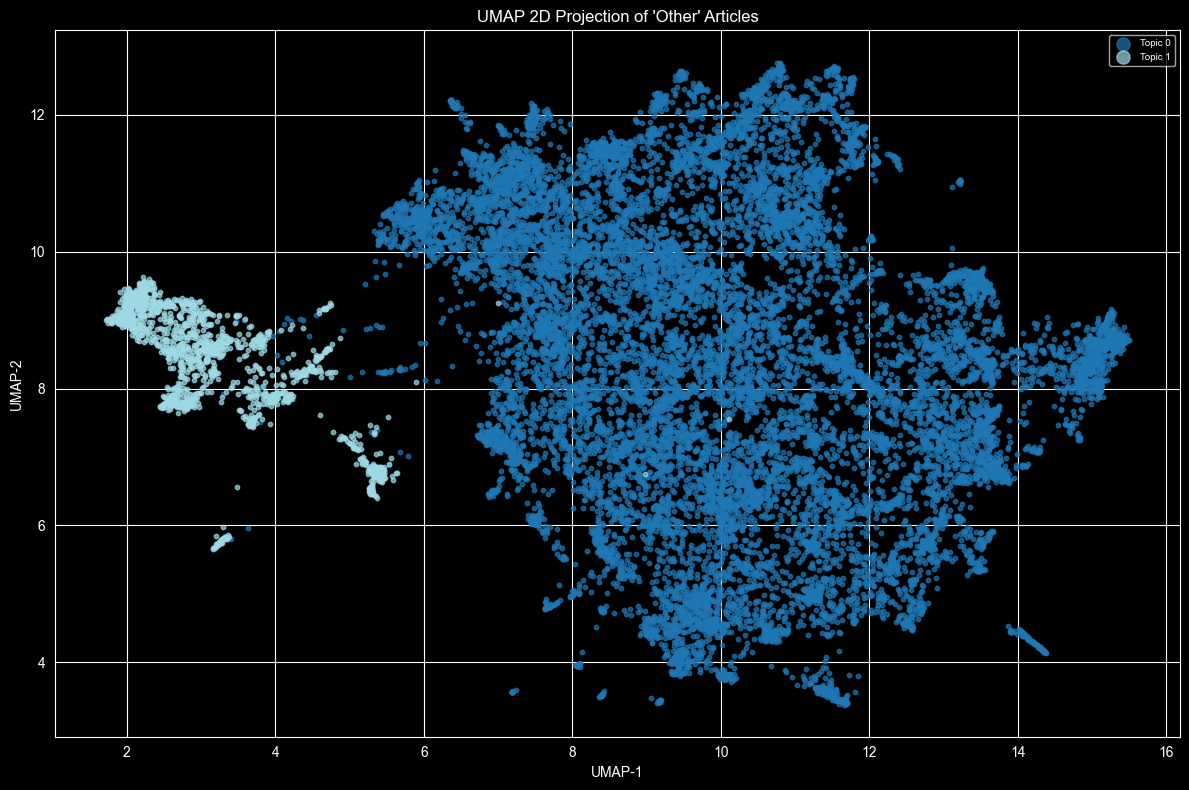

In [19]:
# Visualize clusters in 2D (UMAP projection)
import matplotlib.pyplot as plt
from umap import UMAP as UMAP2D

reducer_2d = UMAP2D(n_components=2, metric='cosine', random_state=42)
emb_2d = reducer_2d.fit_transform(embeddings)

df_other['umap_x'] = emb_2d[:, 0]
df_other['umap_y'] = emb_2d[:, 1]

fig, ax = plt.subplots(figsize=(12, 8))
unique_topics = df_other['topic_id'].unique()
cmap = plt.cm.get_cmap('tab20', len(unique_topics))

for i, tid in enumerate(sorted(unique_topics)):
    mask = df_other['topic_id'] == tid
    label = f'Topic {tid}' if tid != -1 else 'Outlier'
    alpha = 0.2 if tid == -1 else 0.7
    ax.scatter(
        df_other.loc[mask, 'umap_x'],
        df_other.loc[mask, 'umap_y'],
        s=10, color=cmap(i), label=label, alpha=alpha
    )

ax.legend(loc='best', fontsize=7, markerscale=3)
ax.set_title("UMAP 2D Projection of 'Other' Articles")
ax.set_xlabel('UMAP-1')
ax.set_ylabel('UMAP-2')
plt.tight_layout()
plt.savefig('data/other_clusters_umap.png', dpi=150)
plt.show()

## Step 4 — Assign Human-Readable Names to Topics

Review the keyword printout above and fill in this dict. These become your new subtopic candidates.

In [24]:
# EDIT THIS after reviewing topic keywords above
# Example: if topic 2 keywords are 'robot, factory, manufacturing, automation'
TOPIC_NAME_MAP = {
    # topic_id: 'Suggested Subtopic Name'
    0: 'AI & World Politics',
    1: 'Noise',
    # 2: 'AI in Military/Defense',
    -1: 'Outlier / Noise'  # keep as-is
}

df_other['suggested_subtopic'] = df_other['topic_id'].map(TOPIC_NAME_MAP).fillna(
    df_other['topic_id'].apply(lambda x: f'Cluster_{x}' if x != -1 else 'Outlier')
)

df_other['suggested_subtopic'].value_counts()

suggested_subtopic
AI & World Politics    15733
Noise                   1595
Name: count, dtype: int64

## Step 5 — Validate: Sample Articles per Cluster

In [25]:
# Print 3 sample headlines per cluster for manual validation
for name, grp in df_other.groupby('suggested_subtopic'):
    print(f'\n--- {name} ({len(grp)} articles) ---')
    for h in grp['headline'].sample(min(5, len(grp)), random_state=1).tolist():
        print(f'  • {h}')


--- AI & World Politics (15733 articles) ---
  • ‘The actual critique is being lost’: the truth about Jihad Rehab, the year’s most controversial documentary
  • Finland faces growing Russian online threat, Finnish security services say
  • Has France really gone to hell? Its catastrophist discourse is at odds with the facts
  • YouTube’s video games are almost impossible to find – but once you unearth them, you’ll wish you never looked
  • Time running out for UK electoral system to keep up with AI, say regulators

--- Noise (1595 articles) ---
  • Reform’s tales of wasteland Britain won’t work. There’s a far larger market for hope
  • Eddie Howe fears Dan Ashworth could take Newcastle secrets to Old Trafford
  • Amad Diallo ends Manchester United’s European drought by seeing off Paok
  • Alexander Isak, the prodigy who thrived in La Liga, can thrill Newcastle
  • Allardyce ditches bravado and makes ‘brain space’ central to Leeds survival


## Save Output

In [26]:
df_other.to_csv('data/other_clustered.csv', index=False)
print('Saved: data/other_clustered.csv')

# Summary table for your report
summary = (
    df_other.groupby('suggested_subtopic')
    .agg(article_count=('id', 'count'),
         date_min=('date', 'min'),
         date_max=('date', 'max'))
    .sort_values('article_count', ascending=False)
)
print('\nCluster summary:')
summary

Saved: data/other_clustered.csv

Cluster summary:


,article_count,date_min,date_max
suggested_subtopic,,,
AI & World Politics,15733,2022-01-01,2025-12-31
Noise,1595,2022-01-01,2025-12-30


## Next Step

After reviewing the cluster names:
1. Add meaningful clusters back to `SUBTOPIC_KEYWORDS` in `02_classify_subtopics.ipynb`
2. Re-run notebooks 02 → 05 with the expanded subtopic list
3. Clusters with < ~30 articles or incoherent keywords can be kept as 'Niche/Other'